In [81]:
import math
import warnings
from functools import partial
from typing import Any, Callable, Dict, Tuple

import numpy as np

import jax
from jax import numpy as jnp
from jaxtyping import Array, Scalar

from dynamiqs import asqarray, sesolve, sepropagator, timecallable
from dynamiqs.qarrays import QArray
from dynamiqs.time_qarray import TimeQArray
from dynamiqs.method import Method, Tsit5
from dynamiqs.options import Options

from optax import adabelief
from optimistix import minimise, OptaxMinimiser

from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

from blueprint.util.linalg import dag
from blueprint.systems import Transmon
from blueprint.operators import qubit_ops as ops
from blueprint.bases import get_pauli_basis, transform_basis, Basis
from blueprint.drives.envelopes import eval_gaussian_drag_env
from blueprint.drives.pulses import get_gaussian_drag_pulse
from blueprint.operators.metrics import get_gate_fidelity
from blueprint.operators.representations import unitary_to_ptm

In [2]:
type Float = float | Scalar
type Pulse = Callable[[Scalar], Scalar]

In [3]:
def get_figsize(
    columns: int = 1,
    fig_width: float | None = None,
    fig_height: float | None = None,
    width_scale: float = 1.0,
    height_scale: float = 1.0,
) -> Tuple[float, float]:
    """
    get_figsize Returns the figure size for a matplotlib plot that is
    consistent with the IEEE journal template.

    Parameters
    ----------
    columns : int, optional
        The number of text columns that the figure takes up, by default 1
    fig_width : float | None, optional
        The width of the figure in inches, by default None
    fig_height : float | None, optional
        The height of the figure in inches, by default None
    width_scale : float, optional
        A scale factor for the width of the figure, by default 1.0
    height_scale : float, optional
        A scale factor for the height of the figure, by default 1.0

    Returns
    -------
    Tuple[float, float]
        The width and height of the figure in inches.

    Raises
    ------
    ValueError
        If the number of columns is not 1 or 2.
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    max_height = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = 3.4 if columns == 1 else 7
    # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > max_height:
        warnings.warn(
            f"Figure height {fig_height} is too large, setting to {max_height}"
            "inches instead"
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    """
    get_rc_params Returns the matplotlib rcParams for a plot that is consistent with the IEEE journal template.

    Parameters
    ----------
    **kwargs : Any
        Additional keyword arguments to pass to the rcParams. These will override the default values.
        The arguments that have pre-defined values are:
        - "axes.labelsize": 8
        - "axes.titlesize": 8
        - "legend.fontsize": 8
        - "xtick.labelsize": 8
        - "ytick.labelsize": 8
        - "text.usetex": False
        - "font.family": "serif"

    Returns
    -------
    Dict[str, Any]
        The dictionary of rcParams for the plot.
    """
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps", # Commented out because of backened issues
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,  # This should ideally be True, but leads to issues in certain cases.
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

In [4]:
def get_rot_hamiltonian(transmon: Transmon, pulse: Pulse) -> TimeQArray:
    """
    get_rot_hamiltonian Return the system Hamiltonian in the rotating frame as a dynamiqs TimeQArray.

    Parameters
    ----------
    system : System
        Quantum system.

    Returns
    -------
    modulated.TimeQArray
        Time-dependent Hamiltonian for the system in the rotating frame.
    """
    energies = transmon.get_eigenvalues()
    drive_op = transmon.get_charge_op()

    def rot_drive_op(time: Scalar) -> QArray:
        unitary_op = jnp.diag(jnp.exp(1j * time * energies))
        rot_drive_op = pulse(time) * unitary_op @ drive_op @ dag(unitary_op)
        rot_drive_arr = asqarray(rot_drive_op)
        return rot_drive_arr

    rot_hamiltonian = timecallable(rot_drive_op)
    return rot_hamiltonian

In [5]:
def get_drive_amplitude(
    drive_op: Array,
    times: Array,
    envelope: Array,
    rot_angle: float | Scalar,
) -> Scalar:
    """
    get_drive_amplitude Computes the required drive amplitude for a DRAG pulse.

    Parameters
    ----------
    drive_op : Array
        The drive operator matrix.
    times : Array
        The time points for the pulse.
    envelope : Array
        The envelope of the pulse.
    rotation_angle : float | Scalar
        The desired rotation angle.

    Returns
    -------
    Scalar
        The estimated drive amplitude.
    """
    norm_prefactor = jnp.abs(drive_op[0, 1])
    integral = jnp.trapezoid(jnp.abs(envelope), times)
    amplitude = rot_angle / (norm_prefactor * integral)
    return amplitude

In [6]:
@partial(jax.jit, static_argnames=("method", "options"))
def characterize_gate(
    transmon: Transmon,
    amplitude: float | Scalar,
    frequency: float | Scalar,
    phase: float | Scalar,
    duration: float | Scalar,
    gaussian_std: float | Scalar,
    drag_coefficient: float | Scalar,
    basis: Basis,
    method: Method,
    options: Options,
) -> Tuple[Scalar, Scalar]:
    pulse = get_gaussian_drag_pulse(
        amplitude, frequency, phase, duration, gaussian_std, drag_coefficient
    )

    _, states = transmon.get_eigenstates()
    comp_states = states[:, :2]

    times = jnp.linspace(0.0, duration, 2)
    rot_hamiltonian = get_rot_hamiltonian(transmon, pulse)
    result = sepropagator(rot_hamiltonian, times, method=method, options=options)
    unitary_op = jnp.squeeze(result.propagators.to_jax())

    comp_projector = jnp.einsum("ia, ja -> ij", comp_states, jnp.conj(comp_states))
    evolved_projector = unitary_op @ comp_projector @ dag(unitary_op)
    # evolved_projector = dag(target_op) @ evolved_projector @ target_op
    comp_populations = jnp.real(jnp.trace(comp_projector @ evolved_projector))
    leakage_rate = 1.0 - 0.5 * jnp.sum(comp_populations)

    transmon_basis = transform_basis(basis, comp_states)
    ptm = unitary_to_ptm(unitary_op, transmon_basis, transmon_basis)

    return ptm, leakage_rate


@partial(jax.jit, static_argnames=("method", "options"))
def characterize_populations(
    transmon: Transmon,
    times: Array,
    amplitude: float | Scalar,
    frequency: float | Scalar,
    phase: float | Scalar,
    duration: float | Scalar,
    gaussian_std: float | Scalar,
    drag_coefficient: float | Scalar,
    method: Method,
    options: Options,
):
    pulse = get_gaussian_drag_pulse(
        amplitude, frequency, phase, duration, gaussian_std, drag_coefficient
    )

    hamiltonian = get_rot_hamiltonian(transmon, pulse)

    _, states = transmon.get_eigenstates()
    init_states = jnp.matrix_transpose(states)
    init_states = jnp.expand_dims(init_states, -1)

    result = sesolve(hamiltonian, init_states, times, method=method, options=options)
    evolved_states = jnp.squeeze(result.states.to_jax())

    state_overlaps = jnp.einsum(
        "ia, ...bti -> ...abt", jnp.conj(states), evolved_states
    )
    populations = jnp.abs(state_overlaps) ** 2
    return populations

In [7]:
USE_DOUBLE_PRECISION: bool = True
USE_GPU: bool = False
DEVICE_IND: int = 0

if USE_DOUBLE_PRECISION:
    jax.config.update("jax_enable_x64", True)  # Double precision

if USE_GPU:
    cuda_devices = jax.devices("cuda")
    if not cuda_devices:
        raise ValueError("No GPU devices found.")

    device = cuda_devices[DEVICE_IND]
    jax.config.update("jax_default_device", device)

In [8]:
# units
GHZ: Float = 2.0 * math.pi
MHZ: Float = 2e-3 * math.pi
NS: Float = 1.0

In [9]:
TRANSMON_LABEL: str = "transmon"
FREQUENCY: Float = 5.0 * GHZ
ANHARMONICITY: Float = -400.0 * MHZ
OFFSET_CHARGE: Float = 0.0
CHARGE_CUTOFF: int = 200
TRANSMON_DIM: int = 3

In [10]:
DRIVE_LABEL: str = "drive"
GATE_DURATION: Float = 10.0 * NS
GAUSSIAN_STD: Float = 0.25 * GATE_DURATION
ROTATION_ANGLE: Float = 0.5 * math.pi
DRIVE_PHASE: Float = 0.0

In [11]:
METHOD: Method = Tsit5(rtol=1e-15, atol=1e-15, max_steps=1000000)
SEPROP_OPTIONS: Options = Options(save_propagators=False, progress_meter=False)
SESOLVE_OPTIONS: Options = Options(save_states=True, progress_meter=False)

In [12]:
BASIS = get_pauli_basis(normalize=True)

In [13]:
transmon = Transmon.from_frequencies(
    label=TRANSMON_LABEL,
    frequency=FREQUENCY,
    anharmonicity=ANHARMONICITY,
    offset_charge=OFFSET_CHARGE,
    charge_cutoff=CHARGE_CUTOFF,
    dim=TRANSMON_DIM,
)

Calculate the theorethically optimal amplitude, drag coefficient and drive_frequency

In [14]:
drive_frequency: Float = transmon.frequency
drag_coefficient: Float = -1 / transmon.anharmonicity
virtual_phase: Float = 0.0

In [15]:
times = jnp.linspace(0.0, GATE_DURATION, 10000)
envelope = eval_gaussian_drag_env(
    times, GATE_DURATION, GAUSSIAN_STD, drag_coefficient, DRIVE_PHASE
)

charge_op = transmon.get_charge_op()
drive_amplitude = get_drive_amplitude(charge_op, times, envelope, ROTATION_ANGLE)

In [21]:
times = jnp.linspace(0.0, GATE_DURATION, 100)
populations = characterize_populations(
    transmon,
    times,
    drive_amplitude,
    drive_frequency,
    DRIVE_PHASE,
    GATE_DURATION,
    GAUSSIAN_STD,
    drag_coefficient,
    method=METHOD,
    options=SESOLVE_OPTIONS,
)

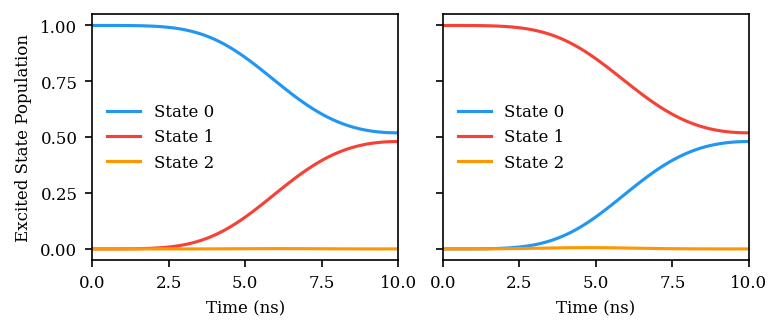

In [93]:
figsize = get_figsize(width_scale=1.5)
rc_params = get_rc_params()

state_inds = jnp.arange(TRANSMON_DIM)
colors = ["#2196f3", "#f44336", "#ff9800"]
with plt.rc_context(rc_params):
    fig, axs = plt.subplots(ncols=2, sharey=True, figsize=figsize, constrained_layout=True, dpi=150)
    ground_ax, exc_ax = axs

    for ind, color in zip(state_inds, colors):
        state_population = populations[ind, 0]
        label = f"State {ind}"
        ground_ax.plot(times / NS, state_population, label=label, color=color)

    ground_ax.legend(frameon=False)
    ground_ax.set_xlim(0, GATE_DURATION / NS)
    ground_ax.set_xlabel("Time (ns)")
    ground_ax.set_ylabel("Excited State Population")

    for ind, color in zip(state_inds, colors):
        state_population = populations[ind, 1]
        label = f"State {ind}"
        exc_ax.plot(times / NS, state_population, label=label, color=color)

    exc_ax.legend(frameon=False)
    exc_ax.set_xlim(0, GATE_DURATION / NS)
    exc_ax.set_xlabel("Time (ns)")

plt.show()

In [16]:
ptm, leakage_rate = characterize_gate(
    transmon,
    drive_amplitude,
    drive_frequency,
    DRIVE_PHASE,
    GATE_DURATION,
    GAUSSIAN_STD,
    drag_coefficient,
    BASIS,
    METHOD,
    SEPROP_OPTIONS,
)

vz_ptm = ops.get_phase_shift(virtual_phase, BASIS)
corrected_ptm = vz_ptm @ ptm @ vz_ptm

target_ptm = ops.get_x_rotation(ROTATION_ANGLE, BASIS)
fidelity = get_gate_fidelity(corrected_ptm, target_ptm, leakage_rate)

print(f"Gate fidelity: {100 * fidelity:.6f} %")
print(f"Leakage rate: {100 * leakage_rate:.9f} %")

Gate fidelity: 99.904207 %
Leakage rate: 0.000004248 %


In [ ]:
red_colors = ["#ffffff","#ffebee", "#ffcdd2", "#ef9a9a", "#e57373", "#ef5350", "#f44336", "#e53935", "#d32f2f", "#c62828", "#b71c1c"]

blue_colors = ["#ffffff", "#e3f2fd", "#bbdefb", "#90caf9", "#64b5f6", "#42a5f5", "#2196f3", "#1e88e5", "#1976d2", "#1565c0", "#0d47a1"]

rev_blue_colors = list(reversed(blue_colors))
redblue_colors = rev_blue_colors + red_colors[1:]
redblue_cmap = LinearSegmentedColormap.from_list("material_redblue", redblue_colors)

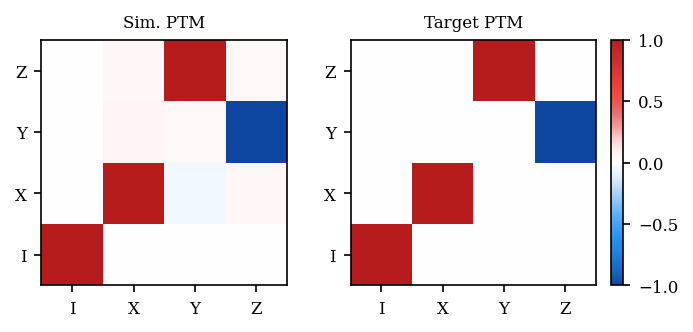

In [ ]:
figsize = get_figsize(width_scale=1.25)
rc_params = get_rc_params()

vmin = -1.0
vmax = 1.0

ticks = np.linspace(0.5, 3.5, 4)
ax_labels = ("I", "X", "Y", "Z")

with plt.rc_context(rc_params):
    fig, axes = plt.subplots(ncols=2, figsize=figsize, constrained_layout=True, dpi=150)

    ax, target_ax = axes
    ax.set_aspect("equal")
    target_ax.set_aspect("equal")

    img = ax.pcolormesh(corrected_ptm, cmap=redblue_cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(ticks, ax_labels)
    ax.set_yticks(ticks, ax_labels)
    ax.set_title("Sim. PTM")

    target_img = target_ax.pcolormesh(target_ptm, cmap=redblue_cmap, vmin=vmin, vmax=vmax)
    target_ax.set_xticks(ticks, ax_labels)
    target_ax.set_yticks(ticks, ax_labels)
    target_ax.set_title("Target PTM")
    
    divider = make_axes_locatable(target_ax)
    colorbar_ax = divider.append_axes("right", size="5%", pad=0.1)
    colorbar = fig.colorbar(img, cax=colorbar_ax)
plt.show()

In [86]:
def min_function(
    params: Tuple[Float, Float, Float, Float],
    args: Tuple[Transmon, Float, Float, Float],
) -> Scalar:
    drive_amplitude, drive_frequency, drag_coefficient, phase = params
    transmon, duration, gaussian_std, rotation_angle = args

    ptm, leakage_rate = characterize_gate(
        transmon,
        drive_amplitude,
        drive_frequency,
        DRIVE_PHASE,
        duration,
        gaussian_std,
        drag_coefficient,
        BASIS,
        METHOD,
        SEPROP_OPTIONS,
    )

    vz_ptm = ops.get_phase_shift(phase, BASIS)
    corrected_ptm = vz_ptm @ ptm @ vz_ptm

    target_ptm = ops.get_x_rotation(rotation_angle, BASIS)
    fidelity = get_gate_fidelity(corrected_ptm, target_ptm, leakage_rate)
    error = 1.0 - fidelity
    return error

In [87]:
init_params = (drive_amplitude, drive_frequency, drag_coefficient, virtual_phase)
args = (transmon, GATE_DURATION, GAUSSIAN_STD, ROTATION_ANGLE)

optimizer = adabelief(learning_rate=1e-4)
solver = OptaxMinimiser(optimizer, rtol=1e-5, atol=1e-5)

solution = minimise(min_function, solver, init_params, args=args, max_steps=100000)

In [94]:
opt_amplitude, opt_frequency, opt_coefficient, opt_virtual_phase = solution.value

In [95]:
print("Optimized parameters:")
print(f"Amplitude: {opt_amplitude}")
print(f"Frequency: {opt_frequency}")
print(f"Drag Coefficient: {opt_coefficient}")
print(f"Virtual Phase: {opt_virtual_phase}")

Optimized parameters:
Amplitude: 0.30220708772040483
Frequency: 31.415910544823507
Drag Coefficient: 0.3580353580340025
Virtual Phase: -0.03919987985000858


In [96]:
ptm, leakage_rate = characterize_gate(
    transmon,
    opt_amplitude,
    opt_frequency,
    DRIVE_PHASE,
    GATE_DURATION,
    GAUSSIAN_STD,
    opt_coefficient,
    BASIS,
    METHOD,
    SEPROP_OPTIONS,
)

vz_ptm = ops.get_phase_shift(opt_virtual_phase, BASIS)
corrected_ptm = vz_ptm @ ptm @ vz_ptm

target_ptm = ops.get_x_rotation(ROTATION_ANGLE, BASIS)
fidelity = get_gate_fidelity(corrected_ptm, target_ptm, leakage_rate)

print(f"Gate fidelity: {100 * fidelity:.6f} %")
print(f"Leakage rate: {100 * leakage_rate:.6f} %")

Gate fidelity: 99.999984 %
Leakage rate: 0.000010 %


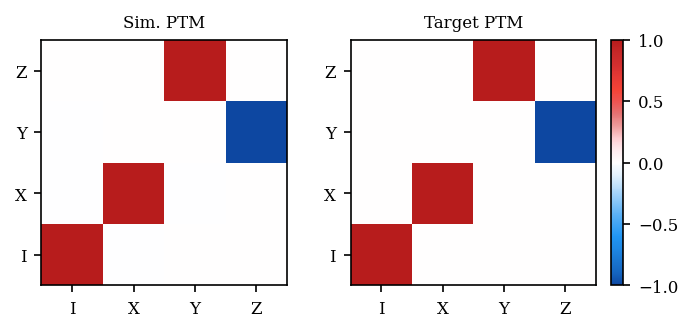

In [97]:
figsize = get_figsize(width_scale=1.25)
rc_params = get_rc_params()

vmin = -1.0
vmax = 1.0

ticks = np.linspace(0.5, 3.5, 4)
ax_labels = ("I", "X", "Y", "Z")

with plt.rc_context(rc_params):
    fig, axes = plt.subplots(ncols=2, figsize=figsize, constrained_layout=True, dpi=150)

    ax, target_ax = axes
    ax.set_aspect("equal")
    target_ax.set_aspect("equal")

    img = ax.pcolormesh(corrected_ptm, cmap=redblue_cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(ticks, ax_labels)
    ax.set_yticks(ticks, ax_labels)
    ax.set_title("Sim. PTM")

    target_img = target_ax.pcolormesh(target_ptm, cmap=redblue_cmap, vmin=vmin, vmax=vmax)
    target_ax.set_xticks(ticks, ax_labels)
    target_ax.set_yticks(ticks, ax_labels)
    target_ax.set_title("Target PTM")
    
    divider = make_axes_locatable(target_ax)
    colorbar_ax = divider.append_axes("right", size="5%", pad=0.1)
    colorbar = fig.colorbar(img, cax=colorbar_ax)
plt.show()

In [98]:
times = jnp.linspace(0.0, GATE_DURATION, 100)
populations = characterize_populations(
    transmon,
    times,
    opt_amplitude,
    opt_frequency,
    DRIVE_PHASE,
    GATE_DURATION,
    GAUSSIAN_STD,
    opt_coefficient,
    method=METHOD,
    options=SESOLVE_OPTIONS,
)

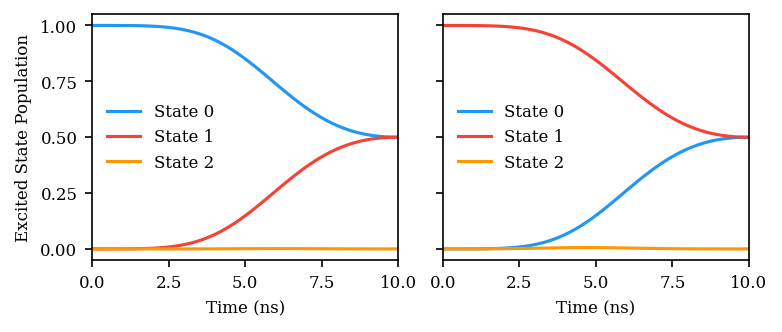

In [99]:
figsize = get_figsize(width_scale=1.5)
rc_params = get_rc_params()

state_inds = jnp.arange(TRANSMON_DIM)
colors = ["#2196f3", "#f44336", "#ff9800"]
with plt.rc_context(rc_params):
    fig, axs = plt.subplots(ncols=2, sharey=True, figsize=figsize, constrained_layout=True, dpi=150)
    ground_ax, exc_ax = axs

    for ind, color in zip(state_inds, colors):
        state_population = populations[ind, 0]
        label = f"State {ind}"
        ground_ax.plot(times / NS, state_population, label=label, color=color)

    ground_ax.legend(frameon=False)
    ground_ax.set_xlim(0, GATE_DURATION / NS)
    ground_ax.set_xlabel("Time (ns)")
    ground_ax.set_ylabel("Excited State Population")

    for ind, color in zip(state_inds, colors):
        state_population = populations[ind, 1]
        label = f"State {ind}"
        exc_ax.plot(times / NS, state_population, label=label, color=color)

    exc_ax.legend(frameon=False)
    exc_ax.set_xlim(0, GATE_DURATION / NS)
    exc_ax.set_xlabel("Time (ns)")

plt.show()